This is a RAG demo for the Cornwall Signposting project, showcasing how responses will be retrieved from our database of organizations and how AI chat responses will be formatted for users.

We map the first level of categories (i.e Budget, Debt & Benefits) to determine which template is sent next, but we dont store this or use to query the database so this wouldn't be sent to the LLM. In our list picker template for the "second level" of options, each option has an id value that is its tag (for example the Budget Advice button has the id "budget-advice"). We use this tag to then search for organizations in our database that contain this tag, and then filter them down by the location specified by the user, for example, if a user searched for national options for budget advice this would be one of the options sent:

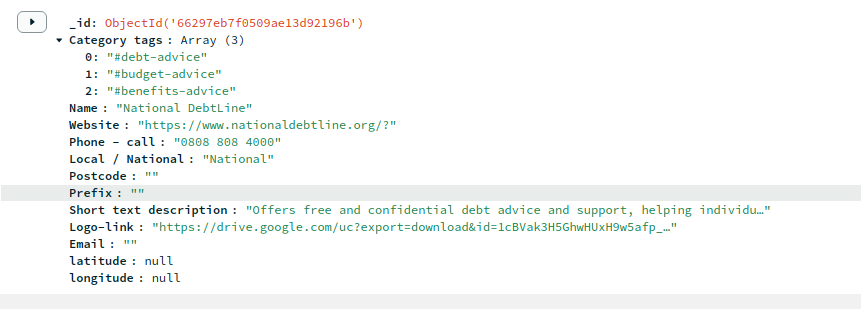

In [1]:
from IPython.display import Image

img_path = './mongoss.png'

Image(filename=img_path)


First for national options, since we will not be using the users postcode I think its best to still query the database with the tag directly and then give the LLM access to the returned data. 

In [2]:
from dotenv import load_dotenv
import os
load_dotenv()
mongodb_uri=os.environ.get("MONGO_URI")

Example: A user selected national options for benefits  advice

In [3]:
from pymongo import MongoClient
client=MongoClient(mongodb_uri)
db=client["signposting_db"]

In [4]:
def get_tagged_options(tag, location_choice, collection_name):
    collection=db[collection_name]
    formatted_tag="#"+tag
    options=collection.find({"Category tags": formatted_tag, "Local / National":location_choice}, projection={"_id":0})
    return list(options)

In [5]:
tag="benefits-advice"
location_choice="National"
collection_name="support_options"
options=get_tagged_options(tag, location_choice, collection_name)
for idx, option in enumerate(options):
    print(f"Option {idx+1}: {option}")

Option 1: {'Category tags': ['#benefits-advice'], 'Name': 'Universal Credit Essentials', 'Website': 'https://www.uceplus.co.uk/about', 'Phone - call': '', 'Local / National': 'National', 'Postcode': '', 'Prefix': '', 'Short text description': 'Charity that aims to make essential financial information and support clear and accessible to the public', 'Logo-link': 'https://drive.google.com/uc?export=download&id=15KM_nAt-QwHTQlPzA4r_mLPyLhq6q44-', 'Email': '', 'latitude': None, 'longitude': None}
Option 2: {'Category tags': ['#debt-advice', '#budget-advice', '#benefits-advice'], 'Name': 'National DebtLine', 'Website': 'https://www.nationaldebtline.org/?', 'Phone - call': '0808 808 4000', 'Local / National': 'National', 'Postcode': '', 'Prefix': '', 'Short text description': 'Offers free and confidential debt advice and support, helping individuals manage debt effectively', 'Logo-link': 'https://drive.google.com/uc?export=download&id=1cBVak3H5GhwHUxH9w5afp_QOK1ki4V9R', 'Email': '', 'latitud

Now here we can first test a language translation, to start we can use the <a href="https://cloud.google.com/translate?_gl=1*798dzz*_up*MQ..&gclid=CjwKCAjw4f6zBhBVEiwATEHFVuPOTRtixKK_9niAwWKVP2aXJ8O-_XBpYRUkdWgbGU5kEmAAEC0EqhoCpY4QAvD_BwE&gclsrc=aw.ds&hl=en#pricing">Cloud Translation API</a> rather than prompting a chat model as it will use a ML model that is tuned for translation, so will be more accurate and likely cheaper

In [6]:
from google.cloud import translate_v2 as translate
import json
translate_client = translate.Client()
def translate_text(text, target_language):
    result = translate_client.translate(text, target_language)
    return result["translatedText"]

Since we only show the website, description name and location for each option, we can extract these and then translate each

In [7]:
def create_input_text(option):
    website=option["Website"]
    if option["Local / National"]=="National":
        location=option["Local / National"]
    else:
        location=option["Postcode"]
    description=option["Short text description"]
    name=option["Name"]
    result={"website": website, "location": location, "description": description, "name": name}
    return result

for option in options:
    print(create_input_text(option))
    

{'website': 'https://www.uceplus.co.uk/about', 'location': 'National', 'description': 'Charity that aims to make essential financial information and support clear and accessible to the public', 'name': 'Universal Credit Essentials'}
{'website': 'https://www.nationaldebtline.org/?', 'location': 'National', 'description': 'Offers free and confidential debt advice and support, helping individuals manage debt effectively', 'name': 'National DebtLine'}
{'website': 'https://www.debtadvicefoundation.org/', 'location': 'National', 'description': 'National debt advice service that aims to prevent and cure unmanageable consumer debt', 'name': 'Debt Advice Foundation'}
{'website': 'https://citizensadvicecornwall.org.uk/', 'location': 'National', 'description': 'Offers free, confidential advice, helping individuals with debt issues and other financial concerns', 'name': "CAB - Citizen's Advice Bureau"}
{'website': 'https://www.moneyhelper.org.uk/en', 'location': 'National', 'description': 'Offers 

Now we can run a tranlsation on the keys and their values and match these together:

In [8]:
option_summaries=[create_input_text(option) for option in options]
def translate_option(option, target_language):
    for key, value in option.items():
        input_str=f"{key}:{value}"
        output_str=translate_text(input_str, target_language)
        print(f"Input: {input_str}")
        print(f"Output: {output_str}")

In [9]:
option_one=option_summaries[0] #trying with one option first
translate_option(option_one, "ru") 
translate_option(option_one, "fr")

Input: website:https://www.uceplus.co.uk/about
Output: сайт: https://www.uceplus.co.uk/about
Input: location:National
Output: расположение:Национальный
Input: description:Charity that aims to make essential financial information and support clear and accessible to the public
Output: описание:Благотворительная организация, целью которой является сделать важную финансовую информацию и поддержку ясной и доступной для общественности.
Input: name:Universal Credit Essentials
Output: название: Universal Credit Essentials
Input: website:https://www.uceplus.co.uk/about
Output: site Web : https://www.uceplus.co.uk/about
Input: location:National
Output: lieu : National
Input: description:Charity that aims to make essential financial information and support clear and accessible to the public
Output: description :Organisation caritative qui vise à rendre les informations financières essentielles et le soutien clairs et accessibles au public
Input: name:Universal Credit Essentials
Output: nom : Les 

Now using a similar function we can build a full text message to send for each option:

In [10]:
def create_translated_message(option, target_language):
    translations=[]
    for key, value in option.items():
        if key !="name":
            input_str=f"{key}: {value}"
            output_str=translate_text(input_str, target_language)
        else:
            translated_key=translate_text(key, target_language)
            output_str=f"{translated_key}: {value}"  #so that we don't translate the name
        translations.append(output_str)
    return "\n".join(translations)
translation=create_translated_message(option_one, "fr")
print(translation)
    

site Web : https://www.uceplus.co.uk/about
lieu : National
description : Organisme caritatif qui vise à rendre les informations financières essentielles et le soutien clairs et accessibles au public
nom: Universal Credit Essentials


So then our chat messages will look like this:

In [11]:
for index, option in enumerate(option_summaries):
    print(f"Message {index+1}")
    translation=create_translated_message(option, "fr")
    print(translation)

Message 1
site Web : https://www.uceplus.co.uk/about
lieu : National
description : Organisme caritatif qui vise à rendre les informations financières essentielles et le soutien clairs et accessibles au public
nom: Universal Credit Essentials
Message 2
Site Web : https://www.nationaldebtline.org/?
lieu : National
description : Offre des conseils et un soutien gratuits et confidentiels en matière d&#39;endettement, aidant ainsi les particuliers à gérer efficacement leurs dettes.
nom: National DebtLine
Message 3
site Web : https://www.debtadvicefoundation.org/
lieu : National
description : Service national de conseil en matière de dette qui vise à prévenir et à guérir les dettes de consommation ingérables
nom: Debt Advice Foundation
Message 4
site Web : https://citizensadvicecornwall.org.uk/
lieu : National
description : Offre des conseils gratuits et confidentiels, aidant les personnes confrontées à des problèmes d&#39;endettement et à d&#39;autres problèmes financiers
nom: CAB - Citizen

Now we can try the logic for sorting by postcode, first we need to get all local options for a category (I set up some logic around this previously so if it doesn't work we can go without AI but it would be helpful to remove all that complexity from the code). For example, these are the local options for debt advice:

In [12]:
options=get_tagged_options("debt-advice","Local", "support_options")
print(options)

[{'Category tags': ['#community-hub', '#homelessness', '#debt-advice'], 'Name': 'Stak Debt Advice', 'Website': 'http://www.stakstaustell.org.uk/', 'Phone - call': '01726 77457', 'Local / National': 'Local', 'Postcode': 'PL25 4AB', 'Prefix': 'PL25', 'Short text description': 'Offers various supports, including housing advice, money matters, food advice, and more', 'Logo-link': 'https://drive.google.com/uc?export=download&id=1-ui4HdG7XzJTYgkSxBlFjS8GR_yABFKo', 'Email': 'alisonpalmer@stakstaustell.org.uk', 'latitude': 50.33856, 'longitude': -4.791159}, {'Category tags': ['#community-hub', '#debt-advice', '#budget-advice', '#employability', '#young-adult', '#community-larder'], 'Name': 'Store House', 'Website': 'https://storehousenewquay.co.uk/', 'Phone - call': '07850 292966', 'Local / National': 'Local', 'Postcode': 'TR7 1BL', 'Prefix': 'TR7', 'Short text description': 'Community hub offering larder and sessions to discuss money issues, including debt, benefits, housing, etc.', 'Logo-lin

In [13]:
option_summaries=[create_input_text(option) for option in options]
print(option_summaries)

[{'website': 'http://www.stakstaustell.org.uk/', 'location': 'PL25 4AB', 'description': 'Offers various supports, including housing advice, money matters, food advice, and more', 'name': 'Stak Debt Advice'}, {'website': 'https://storehousenewquay.co.uk/', 'location': 'TR7 1BL', 'description': 'Community hub offering larder and sessions to discuss money issues, including debt, benefits, housing, etc.', 'name': 'Store House'}, {'website': 'https://smartsavings.org.uk/', 'location': 'TR1 3JJ', 'description': 'Support families throughout Cornwall with free counselling, benefits and debt advice and mindfulness sessions', 'name': 'Smart Savings'}, {'website': 'https://discnewquay.co.uk/', 'location': 'TR7 2QY', 'description': 'Offers various support services regarding ill health, disability, financial hardship or other circumstances', 'name': 'DISC Newquay'}]


To test I'll use a postcode that is super close by:

In [14]:
user_postcode="PL25 5PQ"

In [15]:
import vertexai
from vertexai.generative_models import GenerativeModel
project_id = "ai-signposting"
location="europe-west2"
vertexai.init(project=project_id, location=location)
model = GenerativeModel(model_name="gemini-1.5-flash-001") #using whatever model the tutorial tells me but its nice that switching these seems easy

I'll use a simple function, but we can iterate and improve the prompt later 
 
 <a href="https://cloud.google.com/vertex-ai/generative-ai/docs/model-reference/inference#get-started">API Reference</a>

In [16]:
def sort_by_postcode(list_items, user_postcode, model):
    prompt=f"""Please sort the list of python dictionaries from closest to furthest from the postcode {user_postcode} based on the value of the location key.
    Assume all postcodes are within the UK. Include only the sorted dictionaries in your response, without any additional information or code.
    Dictionaries to sort: 
    {list_items}
    """
    response=model.generate_content(prompt) #A LOT we can configure, customize and set up here, probably not necessary for now though
    print(response.text)
    

In [17]:
list_items=json.dumps(option_summaries)
sort_by_postcode(list_items, user_postcode, model)

[{'website': 'http://www.stakstaustell.org.uk/', 'location': 'PL25 4AB', 'description': 'Offers various supports, including housing advice, money matters, food advice, and more', 'name': 'Stak Debt Advice'}, {'website': 'https://discnewquay.co.uk/', 'location': 'TR7 2QY', 'description': 'Offers various support services regarding ill health, disability, financial hardship or other circumstances', 'name': 'DISC Newquay'}, {'website': 'https://storehousenewquay.co.uk/', 'location': 'TR7 1BL', 'description': 'Community hub offering larder and sessions to discuss money issues, including debt, benefits, housing, etc.', 'name': 'Store House'}, {'website': 'https://smartsavings.org.uk/', 'location': 'TR1 3JJ', 'description': 'Support families throughout Cornwall with free counselling, benefits and debt advice and mindfulness sessions', 'name': 'Smart Savings'}]


I have no idea how accurate that is but its a positive that the first option is definitely the closest one. Now we can refine the above function and prompt to produce a structured output

In [18]:
from vertexai.generative_models import (
    Content,
    FunctionDeclaration,
    Part,
    Tool,
ToolConfig
)
function_name="sort_items_by_postcode"

user_prompt= Content(
    role="user",
    parts=[
        Part.from_text(f"""Please sort the list of python dictionaries from closest to furthest from the postcode {user_postcode} based on the value of the location key.
    Assume all postcodes are within the UK. Include only the sorted dictionaries in your response, without any additional information or code.
    Dictionaries to sort: 
    {list_items}
    """),
    ],
)
sort_items_by_postcode_func=FunctionDeclaration(
  name=function_name,
  description="Sorts the entries by distance from closest to furthest from a given postcode",
  parameters={
      "type": "object",
      "properties": {
          "organizations": {
              "type": "array",
              "description": "A list of information on organizations",
              "items": {
                  "description": "A single organization",
                  "type": "object",
                  "properties": {
                      "name": {"type": "string", "description": "Organization name"},
                      "description": {"type": "string", "description": "A short text description of the organization"},
                       "website": {"type": "string", "description": "the website of the organization"},
                      "location": {"type": "string", "description": "The postcode of the organization to use for sorting"},
                  },
                  "required": ["website", "location", "name", "description"],
              },
          },
      },
      "required": ["organizations"],
  },
)
sorting_tool=Tool(function_declarations=[sort_items_by_postcode_func])
response = model.generate_content(
    user_prompt,
    generation_config={"temperature": 0},
    tools=[sorting_tool],

)
response_function_call_content = response.candidates[0].content.parts[0].to_dict()
organizations=response_function_call_content["function_call"]["args"]["organizations"]
print(organizations)


[{'description': 'Offers various supports, including housing advice, money matters, food advice, and more', 'website': 'http://www.stakstaustell.org.uk/', 'location': 'PL25 4AB', 'name': 'Stak Debt Advice'}, {'description': 'Community hub offering larder and sessions to discuss money issues, including debt, benefits, housing, etc.', 'website': 'https://storehousenewquay.co.uk/', 'location': 'TR7 1BL', 'name': 'Store House'}, {'description': 'Support families throughout Cornwall with free counselling, benefits and debt advice and mindfulness sessions', 'website': 'https://smartsavings.org.uk/', 'location': 'TR1 3JJ', 'name': 'Smart Savings'}, {'description': 'Offers various support services regarding ill health, disability, financial hardship or other circumstances', 'website': 'https://discnewquay.co.uk/', 'location': 'TR7 2QY', 'name': 'DISC Newquay'}]


After, I would use the Twilio API to slice 5 options and send one by one to the user (as previously), so the overall flow would be sorting by location -> translation (if necessary) -> send messages